In [ ]:
## Analysis of Mintflow outputs for renal cell carcinoma dataset
## Macrophage subclustering
## Dr Daniyal Jafree, Lotfollahi Group, CellGen Programme, Wellcome Sanger Institute
## Final Version - 10th July 2025

In [25]:
## Set up environment

# local settings, change path if needed
rootdir_inflow = "/nfs/users/nfs_d/dj17/inflow_version3/inflow"  # Change this path if needed

import spatialdata as sd
from spatialdata_io import xenium
import squidpy as sq
from pathlib import Path
import os, sys
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import anndata
import glasbey
from tqdm.autonotebook import tqdm
import gc
import time
import scvi
import os
import copy

list_pathstoadd = [
    rootdir_inflow,
    os.path.join(rootdir_inflow, "src"),
    os.path.join(rootdir_inflow, "src", "inflow")
]

for path in list_pathstoadd:
    if(path not in sys.path):
        sys.path.append(path)
        
import inflow

from inflow.cli import parse_config_data_train, parse_config_data_test, parse_config_training, parse_config_model

In [2]:
# Set seed
sc.settings.verbosity = 3
sc.settings.seed = 0

# Check if GPU is available
print("GPU Available:", torch.cuda.is_available())
# Check the name of the GPU
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA H100 80GB HBM3


In [3]:
## Specify input path / results folder and inspect adata

path_results = \
"/nfs/team361/dj17/inflow_inputsandoutputs/inflow_outputs/version4_lowanneal" # N.B.: this was a run performed on 5001 raw genes, with the anneal max set to 0.1 but window size is still large

config_data_test = parse_config_data_test.parse(
    os.path.join(
        path_results,
        'ConfigFilesCopiedOver',
        'config_data_test_DJ_v2.yml' # this has to be copied over from the config file list and present within the results folder
    )
)

adata = sc.read_h5ad(
    os.path.join(
        path_results,
        'adata_inflowOutput_norm.h5ad' # this is the normalised object, but change if required
    )
)

print(adata)

AnnData object with n_obs × n_vars = 337116 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'donor', 'inflow_CT', 'inflow_BatchID'
    uns: 'inflow_map_Batchname_to_inflowBatchID', 'inflow_map_CT_to_inflowCT'
    obsm: 'X_scVI', 'X_umap', 'inflow_mu_sin', 'inflow_mu_sout', 'inflow_mu_z', 'inflow_muxbar_int', 'inflow_muxbar_spl', 'inflow_muxint', 'inflow_muxint_before_sc_pp_normalize_total', '

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
adata.obsm

AxisArrays with keys: X_scVI, X_umap, inflow_mu_sin, inflow_mu_sout, inflow_mu_z, inflow_muxbar_int, inflow_muxbar_spl, inflow_muxint, inflow_muxint_before_sc_pp_normalize_total, inflow_muxspl, inflow_muxspl_before_sc_pp_normalize_total, spatial

In [4]:
## Setup object with naming and colouring

dict_map_prednames_2_readable = {
    'muxint':'Xint',
    'muxspl':'Xspl',
    'muxbar_int':'Xbar_int',
    'muxbar_spl':'Xbar_spl',
    'mu_sin':'S_in',
    'mu_sout':'S_out',
    'mu_z':'Z',
    'muxint_before_sc_pp_normalize_total':'Xint_without_scppnormalizetotal',
    'muxspl_before_sc_pp_normalize_total':'Xspl_without_scppnormalizetotal'
}

for k in dict_map_prednames_2_readable.keys():
    print("inflow_"+k in adata.obsm.keys())
    
for k in dict_map_prednames_2_readable.keys():
    adata.obsm['inflow_{}'.format(dict_map_prednames_2_readable[k])] = adata.obsm['inflow_'+k] + 0
    del adata.obsm['inflow_'+k]
    print("done for ", k)
    gc.collect()
    
for u in adata.obsm.keys():
    print(u)
    
type(adata.obsm['inflow_Xspl']) # should be numpy.ndarray

#key_celltype = 'level_2_cell_type'
#colpal = glasbey.create_palette(
    #palette_size=len(set(adata.obs[key_celltype]))
#)
#sns.palplot(colpal)

True
True
True
True
True
True
True
True
True
done for  muxint
done for  muxspl
done for  muxbar_int
done for  muxbar_spl
done for  mu_sin
done for  mu_sout
done for  mu_z
done for  muxint_before_sc_pp_normalize_total
done for  muxspl_before_sc_pp_normalize_total
X_scVI
X_umap
spatial
inflow_Xint
inflow_Xspl
inflow_Xbar_int
inflow_Xbar_spl
inflow_S_in
inflow_S_out
inflow_Z
inflow_Xint_without_scppnormalizetotal
inflow_Xspl_without_scppnormalizetotal


numpy.ndarray

In [8]:
### Predictions are already loaded in in this object, so no need to load them in here

In [95]:
## Macrophage subclustering analysis

adata_macrophage = adata[adata.obs['level_2_cell_type'] == 'Macrophage'].copy() # Subset the AnnData object
print(adata_macrophage)

AnnData object with n_obs × n_vars = 27288 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'donor', 'inflow_CT', 'inflow_BatchID', 'level_4_cell_type'
    uns: 'inflow_map_Batchname_to_inflowBatchID', 'inflow_map_CT_to_inflowCT'
    obsm: 'X_scVI', 'X_umap', 'spatial', 'inflow_Xint', 'inflow_Xspl', 'inflow_Xbar_int', 'inflow_Xbar_spl', 'inflow_S_in', 'inflow_S_out', 'inflow_Z', 'inflow_Xint_w

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)
Took 13.078343152999878 seconds.


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


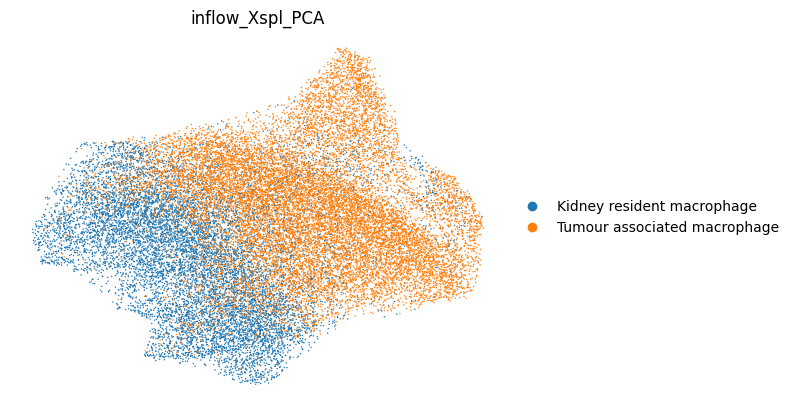

In [96]:
### GENERATES FIGURE 6D

# Perform PCA, nearest neighbors and UMAP based on X spatial for macrophages

t_tic = time.time()
varto_use = 'inflow_Xspl'
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
adata_macrophage.obsm[varto_use+"_PCA"] = pca.fit_transform(adata_macrophage.obsm[varto_use])
sc.pp.neighbors(adata_macrophage, use_rep=varto_use+"_PCA")
sc.tl.umap(adata_macrophage)
sc.pl.umap(
    adata_macrophage,
    color='level_3_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
print("Took {} seconds.".format(time.time() - t_tic))

running Leiden clustering
    finished: found 8 clusters and added
    'spatial clusters', the cluster labels (adata.obs, categorical) (0:00:28)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


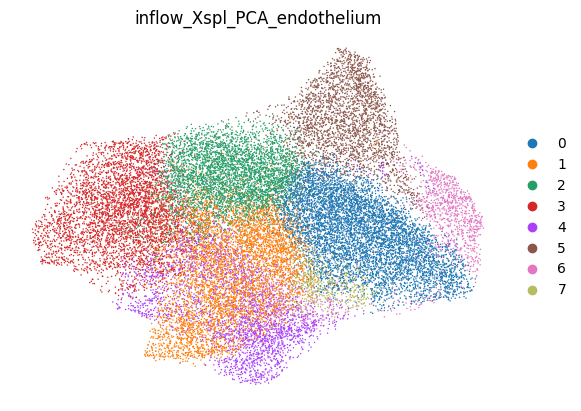

In [99]:
## Identify spatially-defined macrophage subclusters

# Perform Leiden clustering
sc.tl.leiden(adata_macrophage, resolution=0.55, key_added='spatial clusters')

sc.pl.umap(adata_macrophage,
           color=['spatial clusters'],
           title=varto_use + "_PCA_endothelium",
           frameon=False)

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


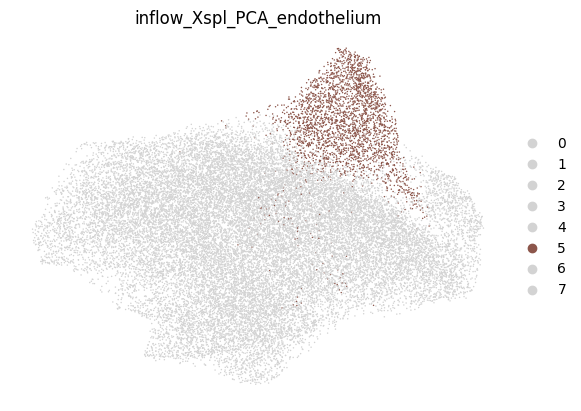

In [101]:
### GENERATES FIGURE 6D

# Get the cluster labels and original colors
clusters = adata_macrophage.obs['spatial clusters'].cat.categories
original_colors = copy.deepcopy(adata_macrophage.uns['spatial clusters_colors'])

# Build custom palette: keep only cluster 5 in original color, gray out the rest
custom_palette = {}
for i, cluster in enumerate(clusters):
    if cluster == '5':  # Adjust if your label is int
        custom_palette[cluster] = original_colors[i]
    else:
        custom_palette[cluster] = 'lightgray'

# Plot UMAP with cluster 5 highlighted
sc.pl.umap(
    adata_macrophage,
    color='spatial clusters',
    palette=custom_palette,
    title=varto_use + "_PCA_endothelium",
    frameon=False
)

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


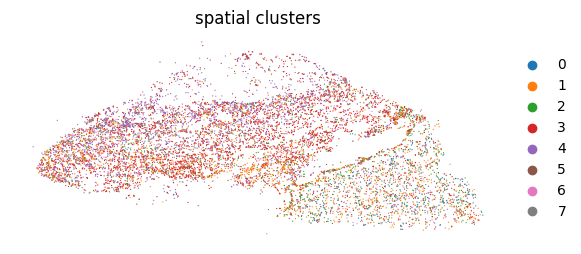

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


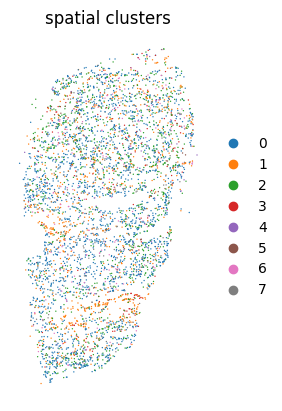

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


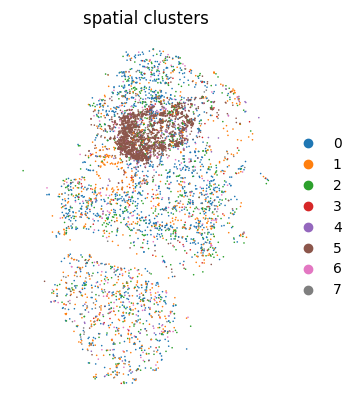

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


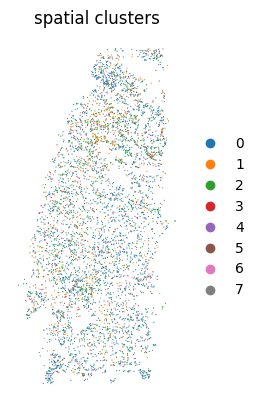

In [100]:
## Spatial plotting of spatially-defined macrophage subclusters

batch_id1 = "CV1-KID-0-FO-1"
batch_id2 = "CV1-KID-0-FT-1"
batch_id3 = "CV1-KID-0-FT-2"
batch_id4 = "CV1-KID-0-FT-3"

adata_macrophage_batch1 = adata_macrophage[adata_macrophage.obs['batch'] == batch_id1]
adata_macrophage_batch2 = adata_macrophage[adata_macrophage.obs['batch'] == batch_id2]
adata_macrophage_batch3 = adata_macrophage[adata_macrophage.obs['batch'] == batch_id3]
adata_macrophage_batch4 = adata_macrophage[adata_macrophage.obs['batch'] == batch_id4]

# Plot spatial data
sc.pl.spatial(adata_macrophage_batch1, color='spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_macrophage_batch2, color='spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_macrophage_batch3, color='spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_macrophage_batch4, color='spatial clusters', size=1.5, spot_size=20, frameon=False)

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


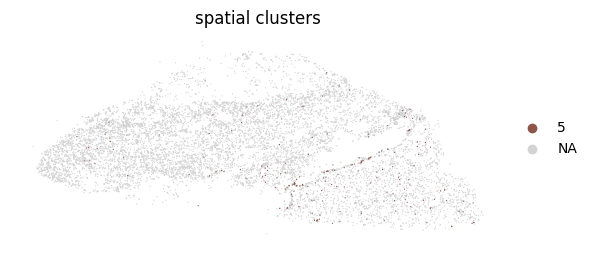

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


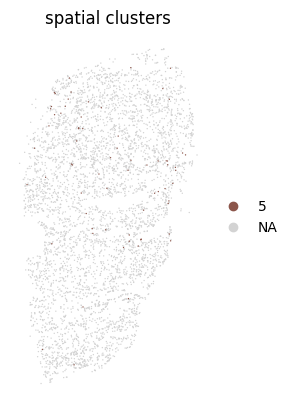

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


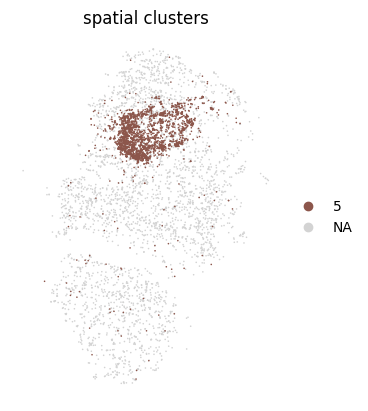

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


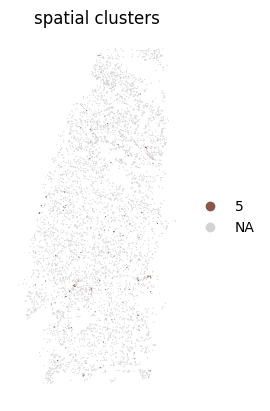

In [114]:
### GENERATES FIGURE 6D

# Define clusters to highlight

#highlight_clusters = ['3', '7', '10'] # Kidney resident macrophage clusters
highlight_clusters = ['5'] # TLS macrophage clusters
#highlight_clusters = ['1', ] # Tumour infiltrating clusters
#highlight_clusters = ['4' ,'6'] # Border-enriched

sc.pl.spatial(adata_macrophage_batch1, color='spatial clusters', groups=highlight_clusters, spot_size=20, size=1.5, frameon=False)
sc.pl.spatial(adata_macrophage_batch2, color='spatial clusters', groups=highlight_clusters, spot_size=20, size=1.5, frameon=False)
sc.pl.spatial(adata_macrophage_batch3, color='spatial clusters', groups=highlight_clusters, spot_size=20, size=1.5, frameon=False)
sc.pl.spatial(adata_macrophage_batch4, color='spatial clusters', groups=highlight_clusters, spot_size=20, size=1.5, frameon=False)

normalizing counts per cell
    finished (0:00:00)
ranking genes


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:07)


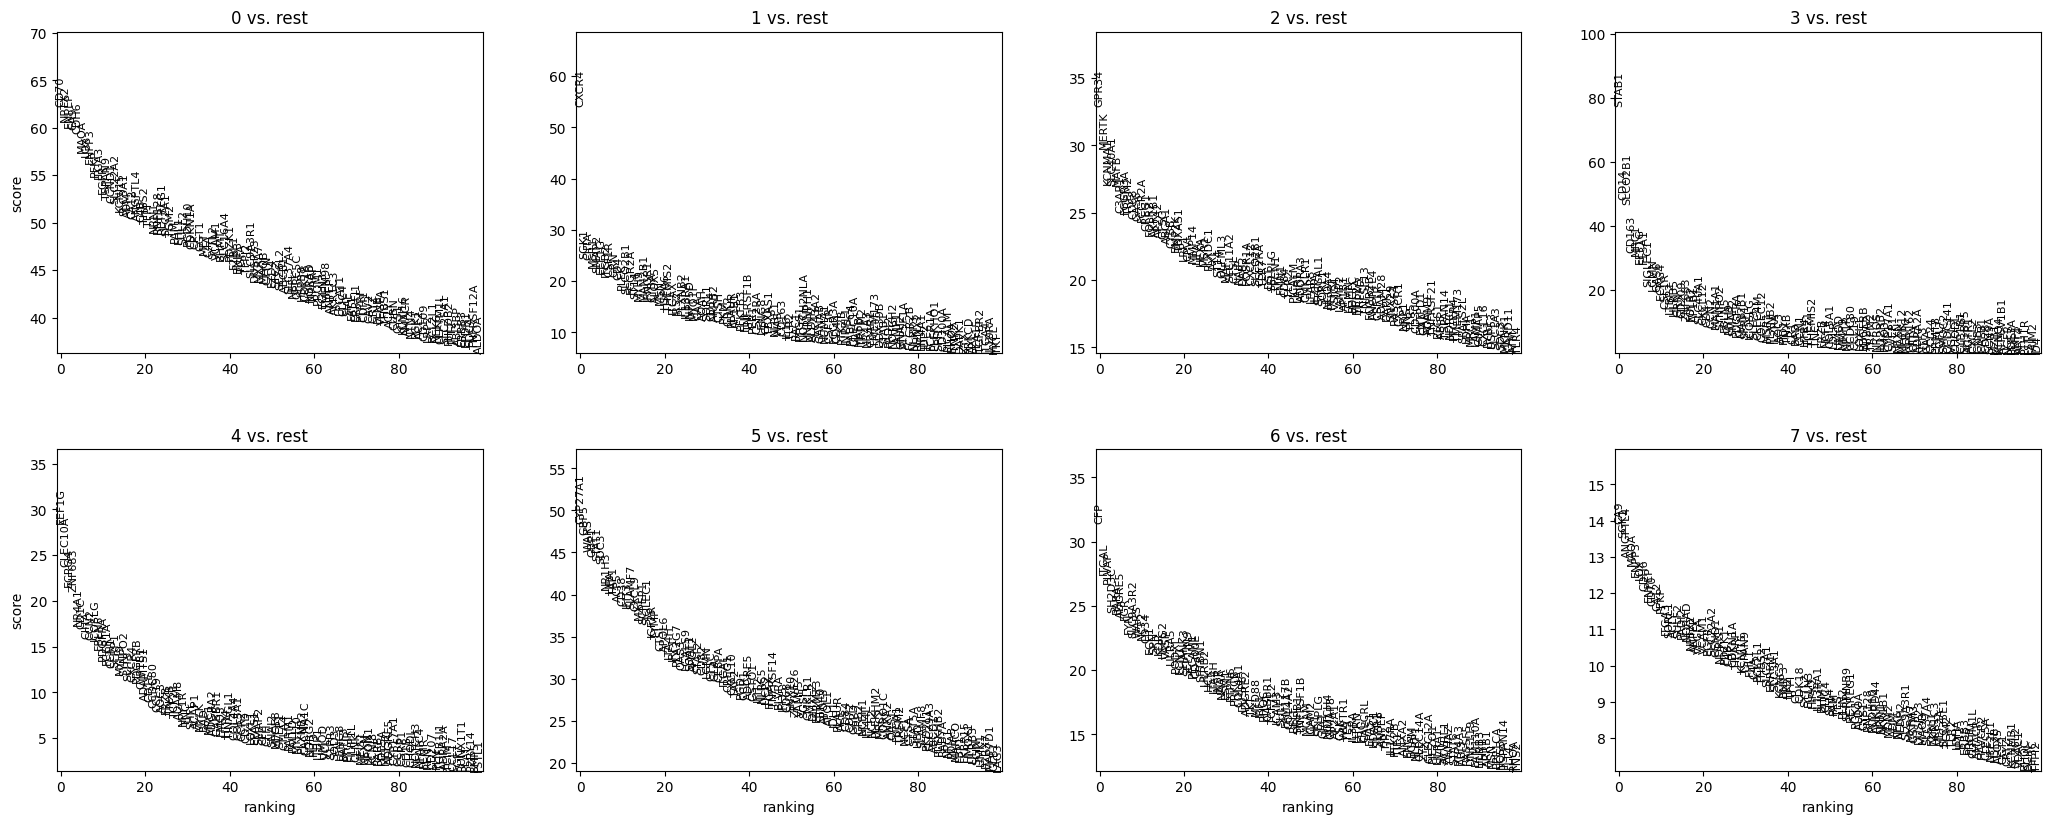

Top genes in 0:
['CD70' 'NPTX2' 'ENPEP' 'CA9' 'CDH6' 'MAOA' 'LOX' 'ENPP3' 'PFKP' 'ITGA3'
 'EGFR' 'TSPAN9' 'CCND1' 'SLC22A2' 'KCNJ15' 'SLC3A1' 'ADM' 'CA12'
 'ANGPTL4' 'C4B' 'THBS2' 'TFPI' 'NRN1' 'RNF128' 'RETREG1' 'SLC2A1' 'TGM2'
 'PAM' 'FHL1' 'SULF2' 'PCDH10' 'CDKN1A' 'CP' 'GGT1' 'MET' 'C4A' 'SYTL2'
 'VCAM1' 'BHMT' 'SLC16A4' 'PDZK1' 'F2RL1' 'BNIP3' 'TGFA' 'TFPI2'
 'SLC9A3R1' 'DUSP23' 'MXRA7' 'MAOB' 'CTTN' 'FZD4' 'STC2' 'SEZ6L2' 'ABCB1'
 'SLC37A4' 'NEFL' 'GPRC5C' 'HSPB8' 'CDK18' 'NORAD' 'TIPARP' 'PROM1'
 'EGLN3' 'TMEM98' 'ANPEP' 'AKR1C3' 'LPCAT1' 'CLIC4' 'SIAE' 'FAT1' 'ERRFI1'
 'PTPRF' 'CDH1' 'CAV2' 'CRYZ' 'FLNB' 'VEGFA' 'THBS1' 'ACLY' 'CUBN' 'GYS1'
 'KCNJ16' 'AMACR' 'NTN4' 'PGK1' 'ACE2' 'CD109' 'LRP2' 'BCL2L1' 'NEK6'
 'CLPTM1L' 'SLC25A1' 'PHLDB2' 'JPT2' 'ABI3BP' 'ERBB3' 'EPDR1' 'SDC4'
 'TNFRSF12A' 'ALDOA' 'SERPINE1' 'ITGB3' 'PPP2R3A' 'CADM3' 'UGT2B7'
 'ZNF608' 'SCIN' 'APOL1' 'SRI' 'WWC1' 'RIPK4' 'SLC35E1' 'PPP2R1A' 'HPCAL1'
 'HNF1B' 'UGT1A9' 'MDM2' 'HNF4A' 'PGM1' 'RHOC' 'LAMP2' 'BCKDK'

In [144]:
## Runs preliminary differential expression tests for macrophages

# Normalize total counts per cell (if not already done)
sc.pp.normalize_total(adata_macrophage, target_sum=1e4)
sc.pp.log1p(adata_macrophage)

# Now run the differential expression analysis using these counts
sc.tl.rank_genes_groups(adata_macrophage, groupby='spatial clusters', method='wilcoxon')
sc.pl.rank_genes_groups(adata_macrophage, n_genes=100, sharey=False)

# Optionally, view the top genes per cluster
result = adata_macrophage.uns['rank_genes_groups']
groups = result['names'].dtype.names  # cluster names
for group in groups:
    print(f"Top genes in {group}:")
    print(result['names'][group][:200])

normalizing counts per cell
    finished (0:00:00)
ranking genes


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)
🔥 Top genes in cluster 5 vs rest:
      genes  logfoldchanges      pvals_adj
0   CYP27A1        3.897383   0.000000e+00
1     STAT1        2.572941   0.000000e+00
2      GBP5        3.857278   0.000000e+00
3      WARS        3.106369   0.000000e+00
4      GBP1        3.427636   0.000000e+00
5      SDC3        2.927271   0.000000e+00
6      LIPA        2.336528   0.000000e+00
7      TAP1        2.447573   0.000000e+00
8     NR1H3        3.058420   0.000000e+00
9      ACP5        4.473897   0.000000e+00
10     CD38        4.082292   0.000000e+00
11    IFIT3        3.661986   0.000000e+00
12   SLAMF7        4.310284   0.00000

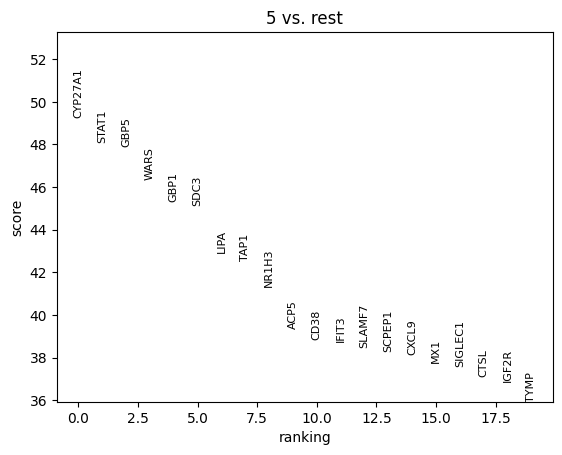

ranking genes


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:07)

🌊 Top genes in rest (non-5) vs cluster 5:
      genes  logfoldchanges      pvals_adj
0     STAB1        1.706045  6.895787e-269
1     CSF1R        0.833617  7.972126e-106
2     CXCR4        0.639210  2.122676e-105
3     AEBP1        1.614370   4.672212e-90
4     F13A1        3.100964   8.745331e-82
5      MRC1        2.169306   3.705931e-70
6     THBS1        1.735395   2.286377e-67
7    CX3CR1        3.312985   1.174912e-65
8      INSR        1.480330   6.262778e-60
9     USP53        2.658290   3.249567e-59
10  TMEM173        1.098575   2.265313e-56
11    SMAP2        0.591706   2.379153e-54
12    PALLD        1.344104 

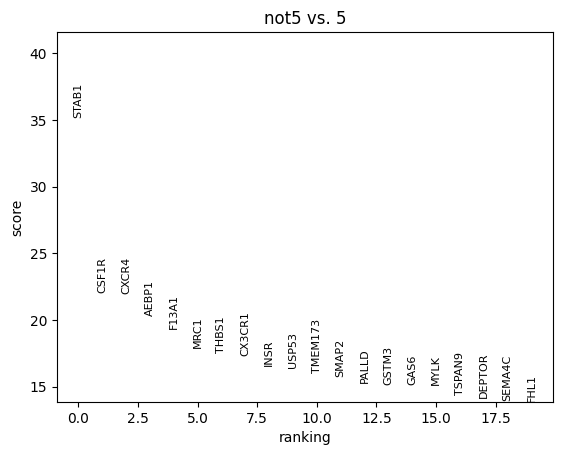

In [117]:
# Normalize and log1p if not already done
sc.pp.normalize_total(adata_macrophage, target_sum=1e4)
sc.pp.log1p(adata_macrophage)

# Step 1: DE: cluster 5 vs rest
sc.tl.rank_genes_groups(
    adata_macrophage,
    groupby='spatial clusters',
    groups=['5'],
    reference='rest',
    method='wilcoxon'
)

# Get top genes in cluster 5
result_5_vs_rest = adata_macrophage.uns['rank_genes_groups']
top_genes_5 = pd.DataFrame({
    'genes': result_5_vs_rest['names']['5'],
    'logfoldchanges': result_5_vs_rest['logfoldchanges']['5'],
    'pvals_adj': result_5_vs_rest['pvals_adj']['5']
})
print("Top genes in cluster 5 vs rest:")
print(top_genes_5.head(20))

# Optional plot
sc.pl.rank_genes_groups(
    adata_macrophage,
    n_genes=20,
    sharey=False
)

# Create a new obs column: '5' vs 'not5'
adata_macrophage.obs['cluster_5_vs_others'] = adata_macrophage.obs['spatial clusters'].astype(str)
adata_macrophage.obs['cluster_5_vs_others'] = adata_macrophage.obs['cluster_5_vs_others'].apply(lambda x: '5' if x == '5' else 'not5')

# Run DE: non-5 vs 5
sc.tl.rank_genes_groups(
    adata_macrophage,
    groupby='cluster_5_vs_others',
    groups=['not5'],
    reference='5',
    method='wilcoxon'
)

# Get top genes in not5
result_rest_vs_5 = adata_macrophage.uns['rank_genes_groups']
top_genes_rest = pd.DataFrame({
    'genes': result_rest_vs_5['names']['not5'],
    'logfoldchanges': result_rest_vs_5['logfoldchanges']['not5'],
    'pvals_adj': result_rest_vs_5['pvals_adj']['not5']
})
print("\n🌊 Top genes in rest (non-5) vs cluster 5:")
print(top_genes_rest.head(20))

# Optional plot
sc.pl.rank_genes_groups(
    adata_macrophage,
    n_genes=20,
    sharey=False
)


computing score 'Interferon Response'
    finished: added
    'Interferon Response', score of gene set (adata.obs).
    547 total control genes are used. (0:00:00)
computing score 'Antigen Presentation'
    finished: added
    'Antigen Presentation', score of gene set (adata.obs).
    198 total control genes are used. (0:00:00)
computing score 'Immune Recruitment/Co-stimulation'
    finished: added
    'Immune Recruitment/Co-stimulation', score of gene set (adata.obs).
    447 total control genes are used. (0:00:00)
computing score 'Phagolysosomal/Scavenger'
    finished: added
    'Phagolysosomal/Scavenger', score of gene set (adata.obs).
    244 total control genes are used. (0:00:00)
computing score 'Lipid Metabolism'
    finished: added
    'Lipid Metabolism', score of gene set (adata.obs).
    397 total control genes are used. (0:00:00)
computing score 'Immunoregulation'
    finished: added
    'Immunoregulation', score of gene set (adata.obs).
    297 total control genes are used

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_stacked_violin.py:405: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pd.DataFrame(_matrix.stack(dropna=False))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_stacked_violin.py:461: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

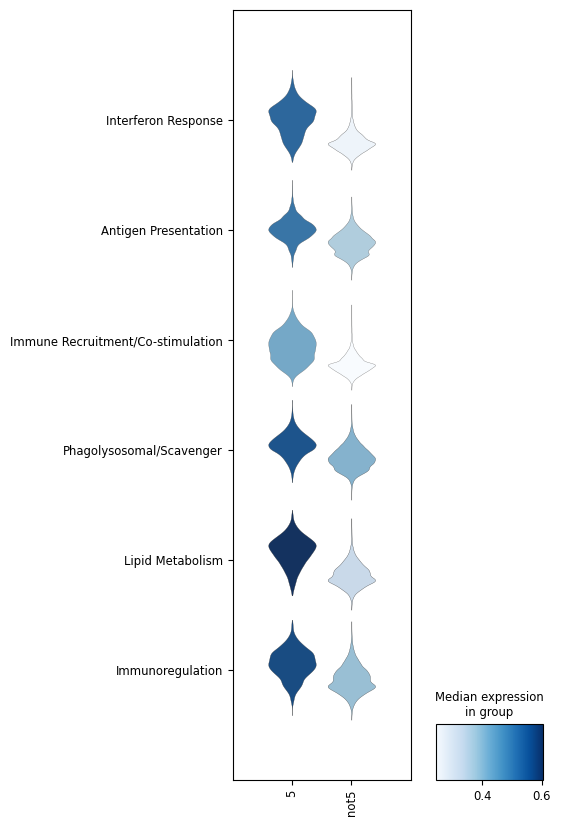

In [148]:
### GENERATES FIGURE 6D

# Step 1: Define curated gene signatures (non-overlapping)
signatures = {
    # Interferon-Stimulated Genes
    'Interferon Response': [
        'STAT1', 'STAT2', 'IRF1', 'IRAK1', 'IFI35', 'IFIT1', 'IFIT2', 'IFIT3', 'IFI44L',
        'RSAD2', 'MX1', 'OAS1', 'OAS3', 'GBP1', 'GBP5', 'UBD', 'TRIM21', 'JAK2'
    ],

    # Antigen Processing and Presentation
    'Antigen Presentation': [
        'TAP1', 'TAP2', 'CTSL', 'CTSC', 'CTSA', 'LAMP1', 'LAMP2', 'ERAP1',
        'CD83', 'CD40'  # Add 'HLA-DRA' if available
    ],

    # Chemokines and Trafficking
    'Immune Recruitment/Co-stimulation': [
        'CXCL9', 'CXCL10', 'CXCL11', 'ICAM1', 'CD84', 'SLAMF7', 'SLAMF8',
        'CD3E', 'IL2RG', 'LAG3', 'TNFSF13B', 'CD44'
    ],

    # Lysosomal and Phagocytosis-Related Genes
    'Phagolysosomal/Scavenger': [
        'CD68', 'LGMN', 'MRC2', 'TREM2', 'FUCA1',
        'NCF1', 'NCF2', 'CYBA', 'GNS', 'GLB1', 'HEXB', 'HEXA', 'GBA', 'SGSH'
    ],

    # Lipid Metabolism and Foam Cell Markers
    'Lipid Metabolism': [
        'LIPA', 'NR1H3', 'PLA2G7', 'SOAT1', 'APOL1', 'APOL2', 'APOL3', 'APOL6',
        'NCEH1', 'SREBF1', 'ABCA1', 'PLIN2', 'NPC1', 'CYP27A1'
    ],

    # Co-Inhibitory Signaling
    'Immunoregulation': [
        'LILRB1', 'LILRB3', 'SIRPA', 'SIRPB1', 'BTK', 'STAT5A', 'TNFRSF14',
        'CMKLR1', 'SP110', 'MAFB', 'TRAFD1'
    ]
}
# Step 2: Score each gene signature and store in .obs
for name, gene_list in signatures.items():
    sc.tl.score_genes(
        adata_macrophage,
        gene_list=gene_list,
        score_name=name
    )

# Step 3: Plot as stacked violin — one row per gene signature
sc.pl.stacked_violin(
    adata_macrophage,
    var_names=list(signatures.keys()),
    groupby='cluster_5_vs_others',
    swap_axes=True,
    standard_scale='var',  # Normalizes signature scores across all cells
    dendrogram=False,
    figsize=(4, 10)
)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', '

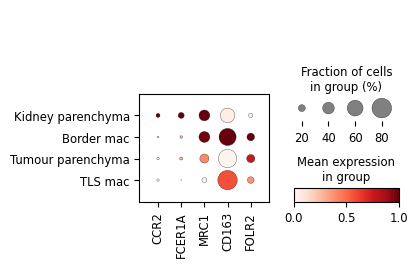

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'inflow_Xspl_PCA'}, xlabel='UMAP1', ylabel='UMAP2'>

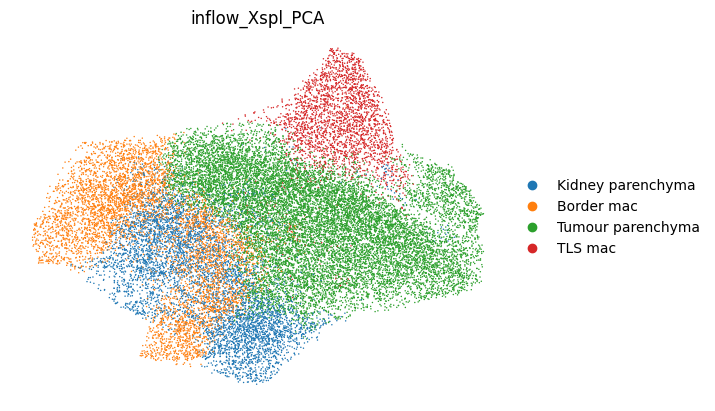

In [87]:
## Examine genes of interest in spatially defined populations

# Ensure spatial cluster labels are strings (just in case)
adata_macrophage.obs['spatial clusters'] = adata_macrophage.obs['spatial clusters'].astype(str)

# Define the mapping from cluster number to label
cluster_name_map = {
    '0': 'Tumour parenchyma',
    '1': 'Tumour parenchyma',
    '2': 'Tumour parenchyma',
    '3': 'Kidney parenchyma',
    '4': 'Border mac',
    '5': 'TLS mac',
    '6': 'Border mac',
    '7': 'Kidney parenchyma',
    '8': 'Tumour parenchyma',
    '9': 'Tumour parenchyma',
    '10': 'Kidney parenchyma'
}


# Create the new column using map
adata_macrophage.obs['MintFlow spatial labels'] = adata_macrophage.obs['spatial clusters'].map(cluster_name_map)

# Set the order of categories for plotting
desired_order = [
    'Kidney parenchyma',
    'Border mac',
    'Tumour parenchyma',
    'TLS mac'
]

adata_macrophage.obs['MintFlow spatial labels'] = pd.Categorical(
    adata_macrophage.obs['MintFlow spatial labels'],
    categories=desired_order,
    ordered=True
)

selected_genes = [
    # Kidney resident enriched
    'CCR2', 'FCER1A', 'MRC1', 'CD163', 'FOLR2', ]

sc.pl.dotplot(adata_macrophage, var_names=selected_genes, groupby='MintFlow spatial labels',
              standard_scale='var'
             )

sc.pl.umap(
    adata_macrophage,
    color='MintFlow spatial labels',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)

In [46]:
# Define output path
output_path = "/nfs/users/nfs_d/dj17/inflow_DJ/macrophage_TLS_cell_ids.txt"

# Filter for cells in cluster '5'
macrophage_TLS_cells = adata_macrophage.obs[adata_macrophage.obs['spatial clusters'] == '5'].index

# Optionally, convert to a list
macrophage_TLS_cell_ids = macrophage_TLS_cells.tolist()

# Save to the specified directory
with open(output_path, "w") as f:
    for cell_id in macrophage_TLS_cell_ids:
        f.write(f"{cell_id}\n")

In [55]:
# Step 1: Load cell IDs from the text file
cell_ids_path = "/nfs/users/nfs_d/dj17/inflow_DJ/macrophage_TLS_cell_ids.txt"

with open(cell_ids_path, 'r') as f:
    tls_macrophage_cell_ids = [line.strip() for line in f.readlines()]

# Step 2: Create 'level_4_cell_type' based on existing 'level_3_cell_type' (or something else)
adata.obs['level_4_cell_type'] = adata.obs['level_3_cell_type'].copy()

# Step 3: Ensure the new label is part of the categories if it's a categorical dtype
if pd.api.types.is_categorical_dtype(adata.obs['level_4_cell_type']):
    adata.obs['level_4_cell_type'] = adata.obs['level_4_cell_type'].cat.add_categories(['TLS_macrophage'])

# Step 4: Update only those cells present in both the file and adata
matching_cell_ids = [cid for cid in tls_macrophage_cell_ids if cid in adata.obs_names]
adata.obs.loc[matching_cell_ids, 'level_4_cell_type'] = 'TLS_macrophage'

#Sanity check
adata.obs['level_4_cell_type'].value_counts()

/tmp/ipykernel_3291281/537933398.py:11: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs['level_4_cell_type']):


level_4_cell_type
Tumour epithelium               141765
Resident fibroblast              28464
Tumour capillary vasculature     27249
CD4+ T lymphocyte                16124
CD8+ T lymphocyte                15772
Cancer associated fibroblast     14450
Tumour associated macrophage     13938
Activated endothelium            11588
Proximal tubule                  10340
Kidney resident macrophage       10304
TLS_macrophage                    9130
Distal tubule                     6285
Vascular smooth muscle            5522
Mixed tubular                     5018
Pericyte                          4586
Peritubular capillary             4548
Loop of Henle                     2495
B lymphocyte                      1960
Mesangial cell                    1461
Podocyte                          1417
Conventional dendritic cell       1148
Glomerular capillary               674
Lymphatic vasculature              459
Mast cell                          422
Name: count, dtype: int64

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


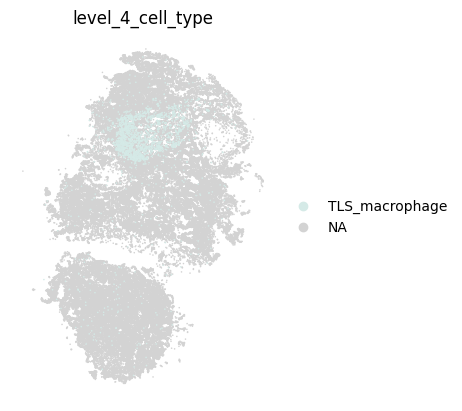

In [56]:
## Spatial plotting of to check assignment

batch_id3 = "CV1-KID-0-FT-2"
adata_batch3 = adata[adata.obs['batch'] == batch_id3]

highlight_clusters = ['TLS_macrophage'] # TLS macrophages

# Plot spatial data
sc.pl.spatial(adata_batch3, color='level_4_cell_type', groups=highlight_clusters, size=1.5, spot_size=20, frameon=False)

normalizing counts per cell
    finished (0:00:00)
ranking genes


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:13)


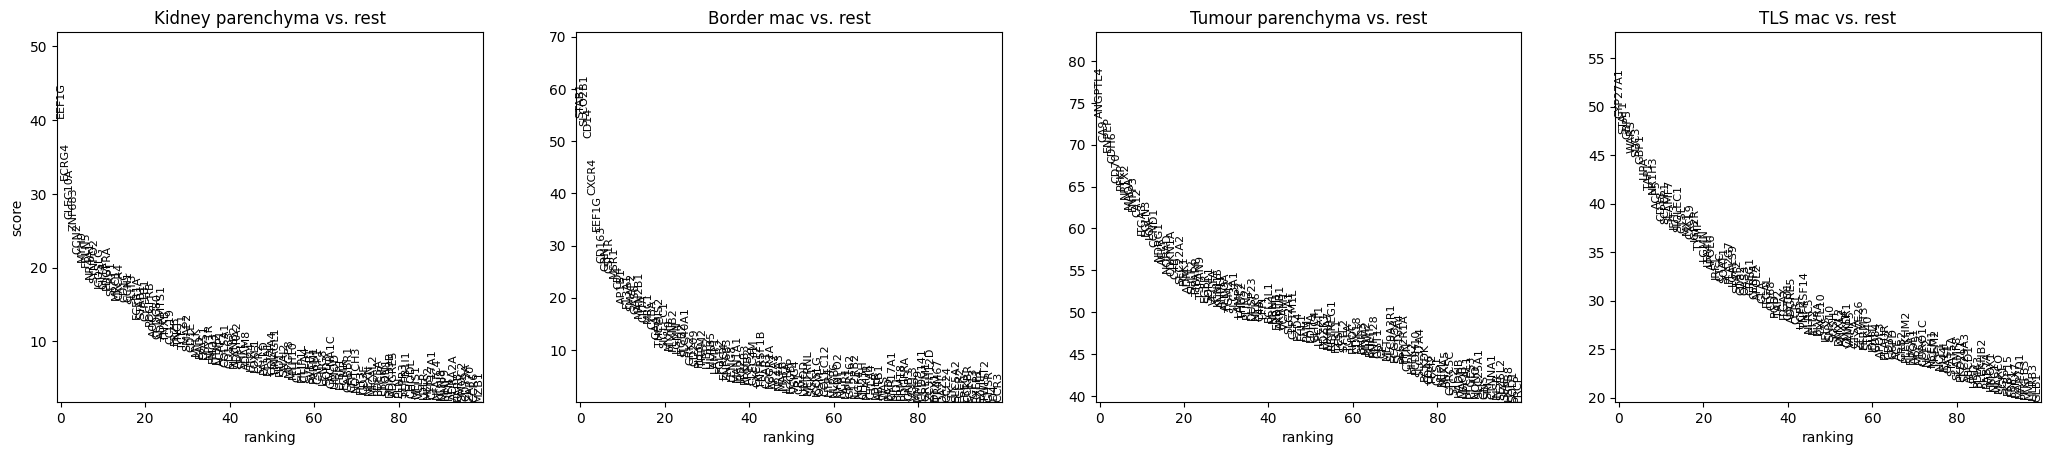

Top genes in Kidney parenchyma:
['EEF1G' 'ECRG4' 'CLEC10A' 'ZNF683' 'CCN2' 'MYH9' 'FBLN5' 'NR4A1' 'SYNPO2'
 'ICOSLG' 'CIITA' 'PDGFRA' 'SFRP1' 'MRC1' 'CXCR4' 'CD1C' 'CCN1' 'SLIT3'
 'FCER1A' 'STAB1' 'CYP1B1' 'PDGFRB' 'AOC3' 'CCDC80' 'ADAMTS1' 'TNXB'
 'CCL19' 'FRZB' 'TNC' 'TCF21' 'SMAP2' 'CD1E' 'MYLK' 'BAD' 'EPAS1' 'NPY1R'
 'FMO3' 'LTBP2' 'ACAP1' 'COL5A1' 'CD163' 'PLXNB2' 'ADGRA2' 'SHFL' 'ADAM8'
 'HTR4' 'LOXL1' 'CCR2' 'PALLD' 'F13A1' 'COL4A4' 'TINAGL1' 'PID1' 'SNAI2'
 'MFGE8' 'MYH10' 'CFH' 'FILIP1L' 'CTLA4' 'SVEP1' 'PARM1' 'CSRP1' 'LENG8'
 'SOD3' 'CACNA1C' 'UMOD' 'LTBP1' 'FCMR' 'GABBR1' 'CFP' 'NOTCH3' 'FLT3'
 'CD3E' 'NEXN' 'MICAL2' 'PDE5A' 'PTGIR' 'SPON1' 'DDX39B' 'ADGRE5' 'PLN'
 'S1PR3' 'TGFB1I1' 'CHODL' 'MEIS1' 'VCL' 'LDLR' 'MEIS2' 'CYP17A1' 'NFATC4'
 'KCNJ8' 'MMP9' 'REN' 'ADRA2A' 'RARB' 'SMOC2' 'CD79A' 'ZAP70' 'CCR6'
 'MZB1']
Top genes in Border mac:
['STAB1' 'SLCO2B1' 'CD14' 'CXCR4' 'EEF1G' 'CD163' 'GRN' 'CSF1R' 'MSR1'
 'CD4' 'AP1B1' 'F13A1' 'SMAP2' 'GAS6' 'MAN2B1' 'CIITA' 'MRC1' 'CYB

In [79]:
## Runs preliminary differential expression tests for macrophages

# Normalize total counts per cell (if not already done)
sc.pp.normalize_total(adata_macrophage, target_sum=1e4)
sc.pp.log1p(adata_macrophage)

# Now run the differential expression analysis using these counts
sc.tl.rank_genes_groups(adata_macrophage, groupby='MintFlow spatial labels', method='wilcoxon')
sc.pl.rank_genes_groups(adata_macrophage, n_genes=100, sharey=False)

# Optionally, view the top genes per cluster
result = adata_macrophage.uns['rank_genes_groups']
groups = result['names'].dtype.names  # cluster names
for group in groups:
    print(f"Top genes in {group}:")
    print(result['names'][group][:100])

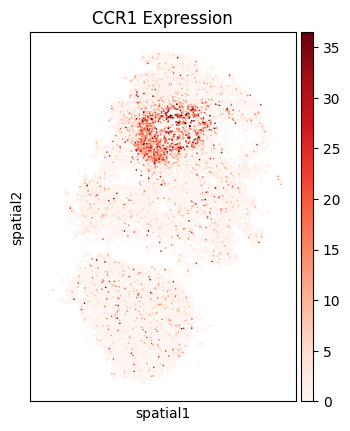

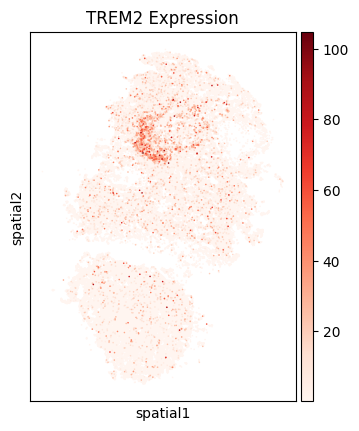

In [165]:
### GENERATES FIGURE 6D

# CCR1
sc.pl.spatial(
    adata_batch3,
    color='CCR1',
    cmap='Reds',
    size=1.5,
    title='CCR1 Expression',
    vmax='p99.9',
    spot_size=20,
    alpha_img=1.0
)

# TREM2
sc.pl.spatial(
    adata_batch3,
    color='TREM2',
    cmap='Reds',   # Different colormap for contrast
    size=1.5,
    title='TREM2 Expression',
    spot_size=20,
    vmin=0.1,
    alpha_img=0.5
)
